In [45]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [46]:
#define State
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [47]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    state['bmi'] = round(bmi, 2)

    return state
    

In [48]:
def level_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']

    if bmi < 18.5:
        state['category'] = "UnderWeight"
    elif 18.5 <= bmi < 25:
        state['category'] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"


    return state

In [49]:
#define your graph
graph = StateGraph(BMIState)

#add nodes
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('level_bmi', level_bmi)

#add Edges
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'level_bmi')
graph.add_edge('level_bmi', END)



In [50]:
#compile the graph
workflow = graph.compile()



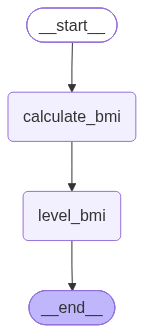

In [51]:
workflow

In [52]:
initial_state = {'weight_kg':80, 'height_m':1.73}


final_state = workflow.invoke(initial_state)

In [53]:
final_state

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}